# 06 XGBoost (extension model)
Part 2: one model not used in the reference paper, trained on the same features, folds and metrics.
Why XGBoost: boosted trees fix the variance problem the paper hits with single trees (train 0.98 vs valid 0.41), support
sample weights for the rare high-price bins, and handle one-hot + numeric features without scaling.

In [1]:
!git clone https://github.com/rosa36-x/funko-ml.git
%cd funko-ml/notebooks
!ls ../data ../src

Cloning into 'funko-ml'...
remote: Enumerating objects: 53, done.
remote: Counting objects: 100% (53/53), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 53 (delta 24), reused 26 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (53/53), 147.76 KiB | 7.78 MiB/s, done.
Resolving deltas: 100% (24/24), done.
/content/funko-ml/notebooks
../data:
data_curated.csv  folds.pkl  processed.npz  processed_table.csv

../src:
evaluate.py  __init__.py


In [2]:
import sys; sys.path.append('../src')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from evaluate import load_data, evaluate_fn, to_row, save_results

In [3]:
d, folds = load_data()
X, y0 = d['X_onehot'], d['y0']
print(X.shape, np.bincount(y0), len(folds))

(359, 59) [146 153  46  10   4] 4


In [4]:
def run(name, params, balanced):
    def fit_predict(tr, te):
        m = XGBClassifier(objective='multi:softprob', random_state=1, n_jobs=1, **params)
        sw = compute_sample_weight('balanced', y0[tr]) if balanced else None
        m.fit(X[tr], y0[tr], sample_weight=sw)
        return m.predict(X[tr]), m.predict(X[te])
    return to_row(name, evaluate_fn(fit_predict, y0, folds))

shallow = dict(n_estimators=100, max_depth=3, learning_rate=0.1)
rows = [
    run('xgboost', {}, False),                       # headline: library defaults
    run('xgboost_balanced', {}, True),               # class-weighted
    run('xgboost_shallow', shallow, False),          # more regularised
    run('xgboost_shallow_balanced', shallow, True),
]
df = pd.DataFrame(rows)
df[['model', 'train_precision', 'train_recall', 'train_f1', 'valid_precision', 'valid_recall', 'valid_f1']]

,model,train_precision,train_recall,train_f1,valid_precision,valid_recall,valid_f1
0,xgboost,0.9628,0.9619,0.9618,0.4519,0.4594,0.4521
1,xgboost_balanced,0.9311,0.9294,0.9294,0.4575,0.4512,0.4510
2,xgboost_shallow,0.7342,0.7177,0.7085,0.4483,0.4820,0.4537
3,xgboost_shallow_balanced,0.7249,0.7029,0.7025,0.4509,0.4262,0.4335


In [5]:
df[['model'] + [f'valid_bin{i}_precision' for i in range(1, 6)]]

,model,valid_bin1_precision,valid_bin2_precision,valid_bin3_precision,valid_bin4_precision,valid_bin5_precision
0,xgboost,0.5022,0.4573,0.3289,0.3750,0.0
1,xgboost_balanced,0.5154,0.4827,0.2105,0.5625,0.0
2,xgboost_shallow,0.5163,0.4641,0.3083,0.0000,0.0
3,xgboost_shallow_balanced,0.5608,0.4565,0.1849,0.1833,0.0


In [6]:
import os
ref = []
for name in ['svm_linear', 'svm_custom', 'dt', 'bagged_dt']:
    path = f'../results/{name}.csv'
    if os.path.exists(path):
        r = pd.read_csv(path)
        if name == 'bagged_dt':
            r = r[r['num_trees'] == 100]
        ref.append(r.iloc[[0]])
cmp = pd.concat(ref + [df[df['model'] == 'xgboost']], ignore_index=True)
cmp[['model', 'train_f1', 'valid_precision', 'valid_recall', 'valid_f1'] + [f'valid_bin{i}_precision' for i in range(1, 6)]]

,model,train_f1,valid_precision,valid_recall,valid_f1,valid_bin1_precision,valid_bin2_precision,valid_bin3_precision,valid_bin4_precision,valid_bin5_precision
0,svm_linear,0.5763,0.4077,0.4819,0.4404,0.4976,0.4818,0.0000,0.000,0.0
1,bagged_dt,0.9833,0.4522,0.4764,0.4557,0.5113,0.4821,0.3006,0.000,0.0
2,xgboost,0.9618,0.4519,0.4594,0.4521,0.5022,0.4573,0.3289,0.375,0.0


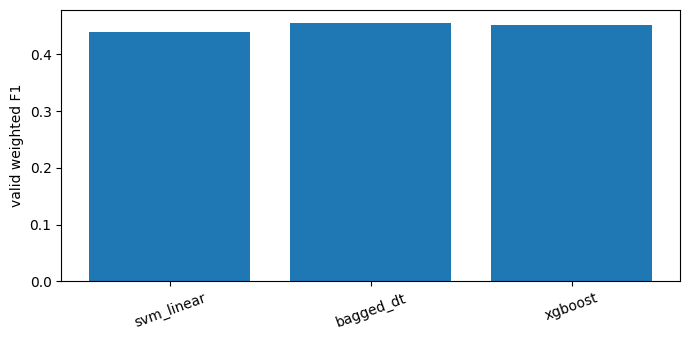

In [7]:
plt.figure(figsize=(7, 3.5))
plt.bar(cmp['model'], cmp['valid_f1'])
plt.ylabel('valid weighted F1'); plt.xticks(rotation=20); plt.tight_layout()
plt.savefig('../results/xgboost_comparison.png', dpi=150); plt.show()

In [8]:
save_results('xgboost', rows)

,model,train_precision,train_recall,train_f1,train_bin1_precision,train_bin2_precision,train_bin3_precision,train_bin4_precision,train_bin5_precision,valid_precision,valid_recall,valid_f1,valid_bin1_precision,valid_bin2_precision,valid_bin3_precision,valid_bin4_precision,valid_bin5_precision
0,xgboost,0.9628,0.9619,0.9618,0.9512,0.9630,1.0000,0.9410,1.0000,0.4519,0.4594,0.4521,0.5022,0.4573,0.3289,0.3750,0.0
1,xgboost_balanced,0.9311,0.9294,0.9294,0.9190,0.9540,0.8855,0.9410,1.0000,0.4575,0.4512,0.4510,0.5154,0.4827,0.2105,0.5625,0.0
2,xgboost_shallow,0.7342,0.7177,0.7085,0.6842,0.7218,0.8915,0.9226,0.7500,0.4483,0.4820,0.4537,0.5163,0.4641,0.3083,0.0000,0.0
3,xgboost_shallow_balanced,0.7249,0.7029,0.7025,0.7287,0.7772,0.5504,0.5881,0.9375,0.4509,0.4262,0.4335,0.5608,0.4565,0.1849,0.1833,0.0


In [9]:
from google.colab import files
files.download('../results/xgboost.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>